In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("monthly_milk_production.csv")
df

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727
...,...,...
163,1975-08,858
164,1975-09,817
165,1975-10,827
166,1975-11,797


In [2]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [4]:
df.shape

(168, 2)

In [5]:
df.isnull().sum()

Date          0
Production    0
dtype: int64

In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


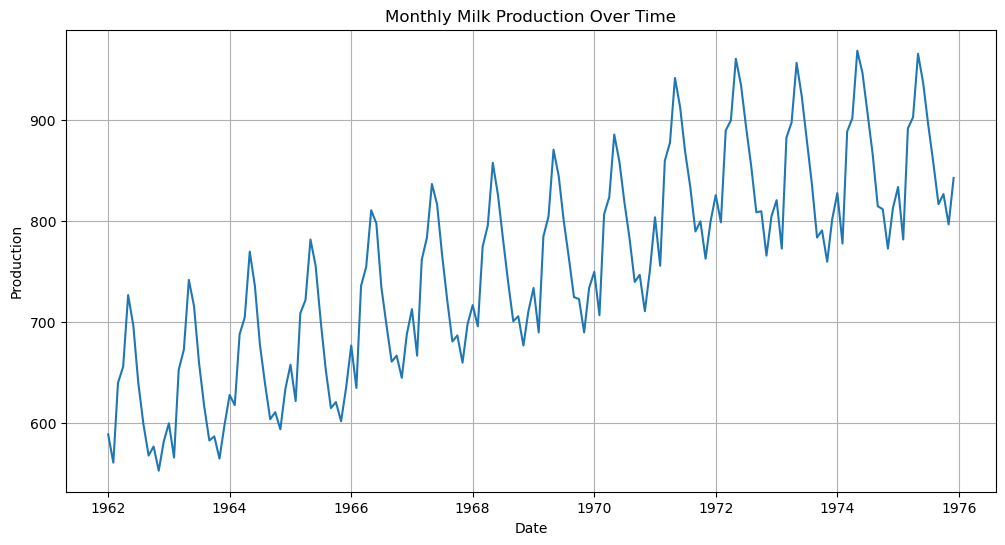

Monthly milk production time series plot displayed.


In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Production'])
plt.title('Monthly Milk Production Over Time')
plt.xlabel('Date')
plt.ylabel('Production')
plt.grid(True)
plt.show()
print("Monthly milk production time series plot displayed.")

In [10]:
print(df['Production'].describe())

count    168.000000
mean     754.708333
std      102.204524
min      553.000000
25%      677.750000
50%      761.000000
75%      824.500000
max      969.000000
Name: Production, dtype: float64


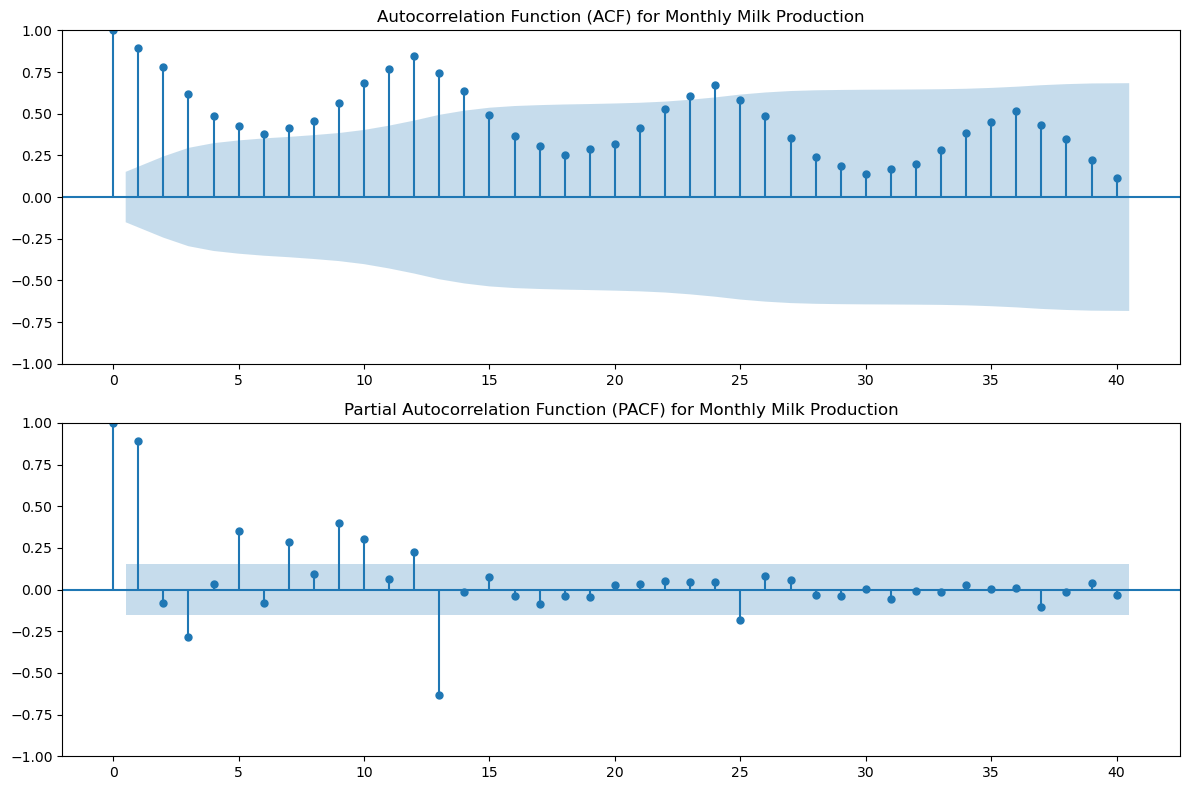

ACF and PACF plots displayed for 'Production' time series.


In [11]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.subplot(211)
plot_acf(df['Production'], ax=plt.gca(), lags=40)
plt.title('Autocorrelation Function (ACF) for Monthly Milk Production')

plt.subplot(212)
plot_pacf(df['Production'], ax=plt.gca(), lags=40)
plt.title('Partial Autocorrelation Function (PACF) for Monthly Milk Production')

plt.tight_layout()
plt.show()
print("ACF and PACF plots displayed for 'Production' time series.")

<Figure size 1200x800 with 0 Axes>

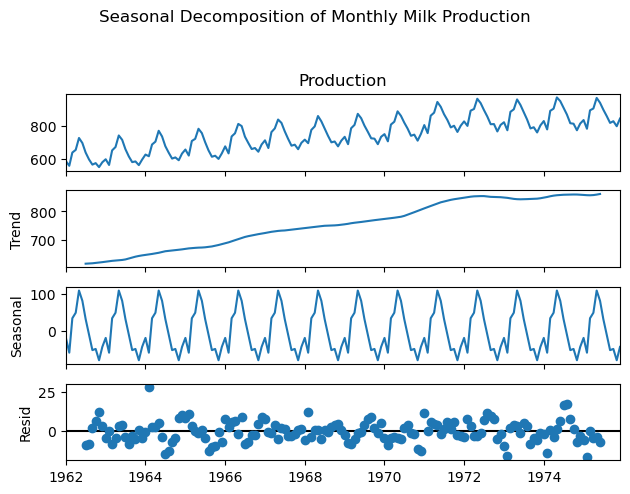

Plot of seasonal decomposition components displayed.


In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Production'], model='additive', period=12)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
decomposition.plot()
plt.suptitle('Seasonal Decomposition of Monthly Milk Production', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()
print("Plot of seasonal decomposition components displayed.")

In [13]:
Q1 = df['Production'].quantile(0.25)
Q3 = df['Production'].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Interquartile Range): {IQR}")

Q1 (25th percentile): 677.75
Q3 (75th percentile): 824.5
IQR (Interquartile Range): 146.75


In [14]:
upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print(f"Upper Bound for Outliers: {upper_bound}")
print(f"Lower Bound for Outliers: {lower_bound}")

Upper Bound for Outliers: 1044.625
Lower Bound for Outliers: 457.625


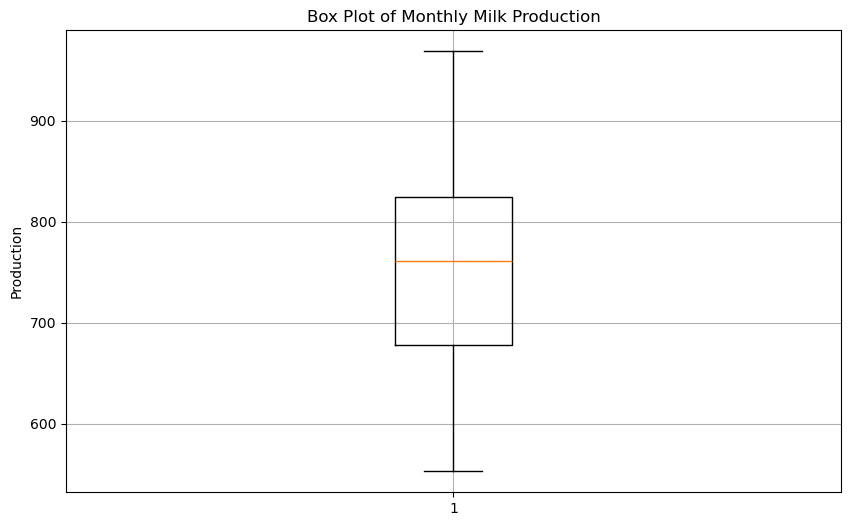

Box plot of 'Production' column displayed.


In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.boxplot(df['Production'])
plt.title('Box Plot of Monthly Milk Production')
plt.ylabel('Production')
plt.grid(True)
plt.show()
print("Box plot of 'Production' column displayed.")

In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df['Production_scaled'] = scaler.fit_transform(df['Production'].values.reshape(-1, 1))
df.head()

,Production,Production_scaled
Date,,
1962-01-01,589,0.086538
1962-02-01,561,0.019231
1962-03-01,640,0.209135
1962-04-01,656,0.247596
1962-05-01,727,0.418269


In [17]:
print(df['Production_scaled'].describe())

count    168.000000
mean       0.484876
std        0.245684
min        0.000000
25%        0.299880
50%        0.500000
75%        0.652644
max        1.000000
Name: Production_scaled, dtype: float64


In [18]:
def create_sequences(data, look_back):
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back)])
        y.append(data[i + look_back])
    return np.array(X), np.array(y)

print("The 'create_sequences' function has been defined.")

The 'create_sequences' function has been defined.


In [19]:
look_back = 12
X, y = create_sequences(df['Production_scaled'].values, look_back)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (156, 12)
y shape: (156,)


In [20]:
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size + val_size], y[train_size:train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (109, 12), y_train shape: (109,)
X_val shape: (23, 12), y_val shape: (23,)
X_test shape: (24, 12), y_test shape: (24,)


In [21]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Reshaped X_train shape: {X_train.shape}")
print(f"Reshaped X_val shape: {X_val.shape}")
print(f"Reshaped X_test shape: {X_test.shape}")

Reshaped X_train shape: (109, 12, 1)
Reshaped X_val shape: (23, 12, 1)
Reshaped X_test shape: (24, 12, 1)


In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# 2. Create a Sequential model instance
model = Sequential()

# 3. Add a SimpleRNN layer
# The input_shape is (timesteps, features). In our case, look_back is timesteps and 1 feature.
model.add(SimpleRNN(units=50, activation='relu', input_shape=(look_back, 1)))

# 4. Add a Dense layer with one unit as the output layer
model.add(Dense(units=1))

# 5. Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()
print("RNN model defined and compiled successfully.")

C:\Users\yaram\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)             │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

RNN model defined and compiled successfully.


In [39]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=1)
print("RNN model training complete.")

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 215ms/step - loss: 0.6481 - val_loss: 1.3294
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 0.4688 - val_loss: 0.9895
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.3461 - val_loss: 0.7492
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - loss: 0.2591 - val_loss: 0.5762
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.1947 - val_loss: 0.4231
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.1345 - val_loss: 0.2672
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0737 - val_loss: 0.1203
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0386 - val_loss: 0.0308
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0423 - val_loss: 0.0264
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 0.0367 - val_loss: 0.0333
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 0.0271 - val_loss: 0.0466
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0267 - val_loss: 0.0546

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# 2. Create a Sequential model instance
model_lstm = Sequential()

# 3. Add an Input layer to explicitly define the input shape
model_lstm.add(Input(shape=(look_back, 1)))

# 4. Add an LSTM layer with 50 units and 'relu' activation
model_lstm.add(LSTM(units=50, activation='relu'))

# 5. Add a Dense layer with one unit as the output layer
model_lstm.add(Dense(units=1))

# 6. Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# 7. Print a summary of the model
model_lstm.summary()
print("LSTM model defined and compiled successfully.")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

LSTM model defined and compiled successfully.


In [26]:
history_lstm = model_lstm.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=1)
print("LSTM model training complete.")

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 257ms/step - loss: 0.1689 - val_loss: 0.3554
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.1354 - val_loss: 0.2778
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.1036 - val_loss: 0.2083
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0771 - val_loss: 0.1418
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0507 - val_loss: 0.0804
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0315 - val_loss: 0.0345
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0241 - val_loss: 0.0255
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - loss: 0.0281 - val_loss: 0.0288
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0279 - val_loss: 0.0243
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 0.0235 - val_loss: 0.0267
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - loss: 0.0226 - val_loss: 0.0331
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0233 - val_loss: 0.033

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Input

# 2. Create a Sequential model instance
model_gru = Sequential()

# 3. Add an Input layer to explicitly define the input shape
model_gru.add(Input(shape=(look_back, 1)))

# 4. Add a GRU layer with 50 units and 'relu' activation
model_gru.add(GRU(units=50, activation='relu'))

# 5. Add a Dense layer with one unit as the output layer
model_gru.add(Dense(units=1))

# 6. Compile the model
model_gru.compile(optimizer='adam', loss='mean_squared_error')

# 7. Print a summary of the model
model_gru.summary()
print("GRU model defined and compiled successfully.")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 50)                  │           7,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

GRU model defined and compiled successfully.


In [29]:
history_gru = model_gru.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_val, y_val), verbose=1)
print("GRU model training complete.")

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0113 - val_loss: 0.0136
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0113 - val_loss: 0.0122
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0112 - val_loss: 0.0132
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 0.0109 - val_loss: 0.0154
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.0109 - val_loss: 0.0142
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - loss: 0.0107 - val_loss: 0.0130
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0107 - val_loss: 0.0128
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0106 - val_loss: 0.0146
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0106 - val_loss: 0.0137
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0105 - val_loss: 0.0118
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0102 - val_loss: 0.0137
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0102 - val_loss: 0.0133
E

In [30]:
test_loss_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print(f"GRU Model Test Loss: {test_loss_gru:.4f}")

GRU Model Test Loss: 0.0099


In [31]:
y_pred_rnn = model.predict(X_test)
y_pred_lstm = model_lstm.predict(X_test)
y_pred_gru = model_gru.predict(X_test)

# Inverse transform the actual test values
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Inverse transform the predictions
y_pred_rnn_inv = scaler.inverse_transform(y_pred_rnn)
y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm)
y_pred_gru_inv = scaler.inverse_transform(y_pred_gru)

print("Predictions generated and inverse scaled for RNN, LSTM, and GRU models.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step
Predictions generated and inverse scaled for RNN, LSTM, and GRU models.


In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

def calculate_mape(y_true, y_pred):
    # Avoid division by zero by replacing zeros in y_true with a small epsilon or filtering them out
    # For milk production, values are always positive, so direct calculation is fine.
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("Metrics and plotting libraries imported and MAPE function defined.")

Metrics and plotting libraries imported and MAPE function defined.



--- Model Evaluation Metrics ---
RNN RMSE: 15.4637
LSTM RMSE: 119.5332
GRU RMSE: 41.4708
RNN MAE: 11.1959
LSTM MAE: 91.8379
GRU MAE: 28.6193
RNN MAPE: 1.3348%
LSTM MAPE: 10.4874%
GRU MAPE: 3.3718%


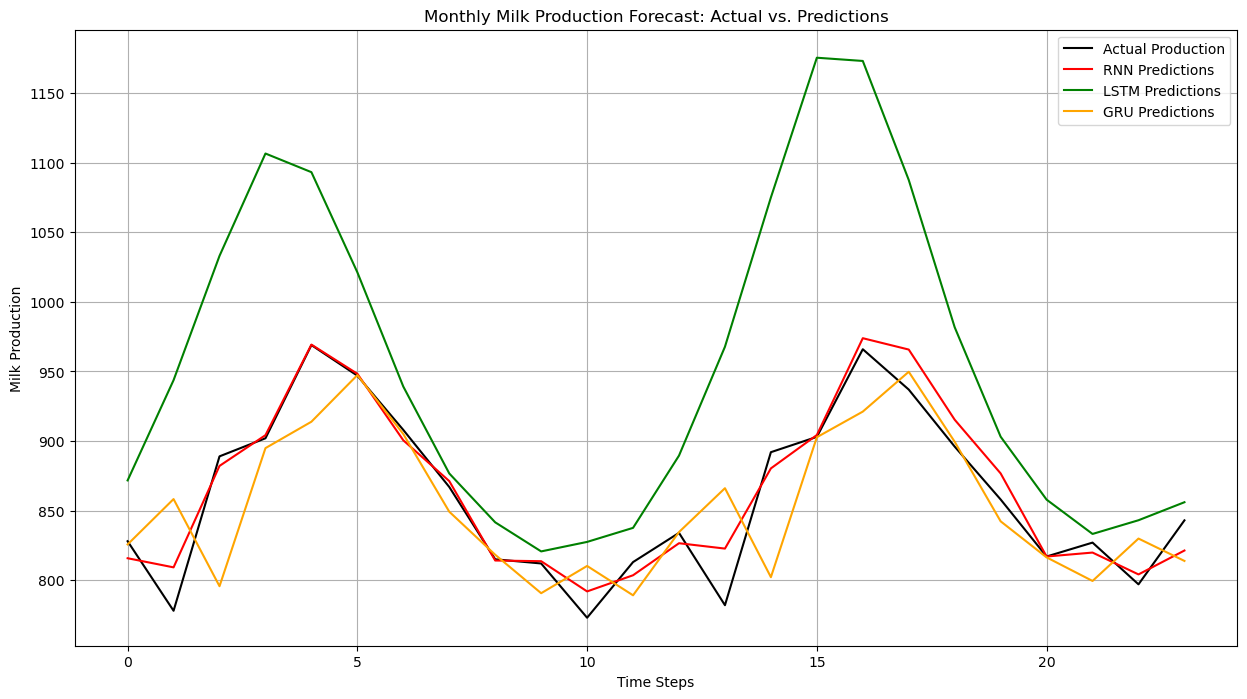

Evaluation metrics calculated and comparative plot displayed.


In [33]:
print("\n--- Model Evaluation Metrics ---")

# Calculate RMSE for each model
rmse_rnn = np.sqrt(mean_squared_error(y_test_inv, y_pred_rnn_inv))
rmse_lstm = np.sqrt(mean_squared_error(y_test_inv, y_pred_lstm_inv))
rmse_gru = np.sqrt(mean_squared_error(y_test_inv, y_pred_gru_inv))

print(f"RNN RMSE: {rmse_rnn:.4f}")
print(f"LSTM RMSE: {rmse_lstm:.4f}")
print(f"GRU RMSE: {rmse_gru:.4f}")

# Calculate MAE for each model
mae_rnn = mean_absolute_error(y_test_inv, y_pred_rnn_inv)
mae_lstm = mean_absolute_error(y_test_inv, y_pred_lstm_inv)
mae_gru = mean_absolute_error(y_test_inv, y_pred_gru_inv)

print(f"RNN MAE: {mae_rnn:.4f}")
print(f"LSTM MAE: {mae_lstm:.4f}")
print(f"GRU MAE: {mae_gru:.4f}")

# Calculate MAPE for each model
mape_rnn = calculate_mape(y_test_inv, y_pred_rnn_inv)
mape_lstm = calculate_mape(y_test_inv, y_pred_lstm_inv)
mape_gru = calculate_mape(y_test_inv, y_pred_gru_inv)

print(f"RNN MAPE: {mape_rnn:.4f}%")
print(f"LSTM MAPE: {mape_lstm:.4f}%")
print(f"GRU MAPE: {mape_gru:.4f}%")

# Plotting the results
plt.figure(figsize=(15, 8))
plt.plot(y_test_inv, label='Actual Production', color='black')
plt.plot(y_pred_rnn_inv, label='RNN Predictions', color='red')
plt.plot(y_pred_lstm_inv, label='LSTM Predictions', color='green')
plt.plot(y_pred_gru_inv, label='GRU Predictions', color='orange')

plt.title('Monthly Milk Production Forecast: Actual vs. Predictions')
plt.xlabel('Time Steps')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True)
plt.show()

print("Evaluation metrics calculated and comparative plot displayed.")


In [34]:
last_date = df.index.max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')

print(f"Last date in original dataset: {last_date}")
print("Generated future dates for forecasting:")
print(future_dates)

Last date in original dataset: 1975-12-01 00:00:00
Generated future dates for forecasting:
DatetimeIndex(['1976-01-01', '1976-02-01', '1976-03-01', '1976-04-01',
               '1976-05-01', '1976-06-01', '1976-07-01', '1976-08-01',
               '1976-09-01', '1976-10-01', '1976-11-01', '1976-12-01'],
              dtype='datetime64[ns]', freq='MS')


In [35]:
last_12_months_scaled = df['Production_scaled'].values[-look_back:]
print(f"Last {look_back} months of scaled production values:\n{last_12_months_scaled}")

Last 12 months of scaled production values:
[0.67548077 0.55048077 0.81490385 0.84134615 0.99278846 0.92307692
 0.82451923 0.73317308 0.63461538 0.65865385 0.58653846 0.69711538]


In [36]:
n_forecast_steps = 12

# --- RNN Model Forecasting ---
rnn_forecast = []
current_input_rnn = last_12_months_scaled.tolist()
for _ in range(n_forecast_steps):
    # Reshape input to (1, look_back, 1) for the model
    input_seq_rnn = np.array(current_input_rnn[-look_back:]).reshape(1, look_back, 1)
    predicted_value_rnn = model.predict(input_seq_rnn)[0][0]
    rnn_forecast.append(predicted_value_rnn)
    current_input_rnn.append(predicted_value_rnn)

# --- LSTM Model Forecasting ---
lstm_forecast = []
current_input_lstm = last_12_months_scaled.tolist()
for _ in range(n_forecast_steps):
    # Reshape input to (1, look_back, 1) for the model
    input_seq_lstm = np.array(current_input_lstm[-look_back:]).reshape(1, look_back, 1)
    predicted_value_lstm = model_lstm.predict(input_seq_lstm)[0][0]
    lstm_forecast.append(predicted_value_lstm)
    current_input_lstm.append(predicted_value_lstm)

# --- GRU Model Forecasting ---
gru_forecast = []
current_input_gru = last_12_months_scaled.tolist()
for _ in range(n_forecast_steps):
    # Reshape input to (1, look_back, 1) for the model
    input_seq_gru = np.array(current_input_gru[-look_back:]).reshape(1, look_back, 1)
    predicted_value_gru = model_gru.predict(input_seq_gru)[0][0]
    gru_forecast.append(predicted_value_gru)
    current_input_gru.append(predicted_value_gru)

# Inverse transform the forecasts to original scale
rnn_forecast_inv = scaler.inverse_transform(np.array(rnn_forecast).reshape(-1, 1))
lstm_forecast_inv = scaler.inverse_transform(np.array(lstm_forecast).reshape(-1, 1))
gru_forecast_inv = scaler.inverse_transform(np.array(gru_forecast).reshape(-1, 1))

print("12-month forecasts generated and inverse scaled for RNN, LSTM, and GRU models.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━

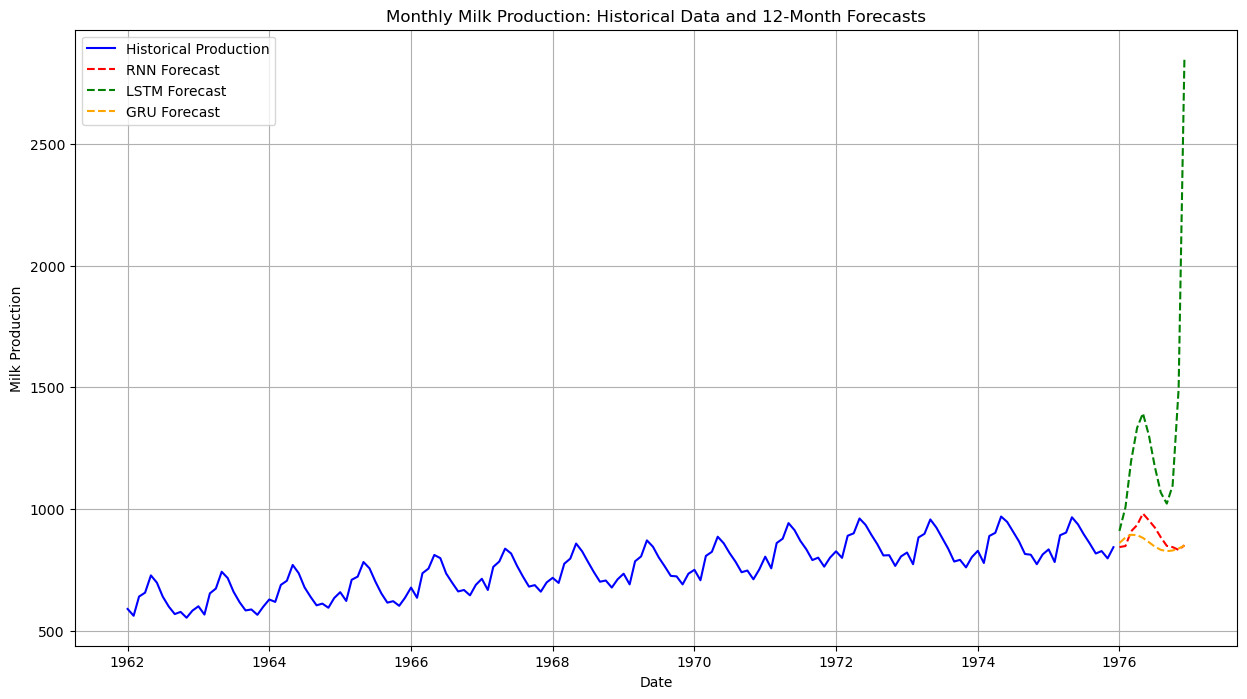

Historical data with 12-month forecasts from RNN, LSTM, and GRU models displayed.


In [37]:
plt.figure(figsize=(15, 8))
plt.plot(df.index, df['Production'], label='Historical Production', color='blue')
plt.plot(future_dates, rnn_forecast_inv, label='RNN Forecast', color='red', linestyle='--')
plt.plot(future_dates, lstm_forecast_inv, label='LSTM Forecast', color='green', linestyle='--')
plt.plot(future_dates, gru_forecast_inv, label='GRU Forecast', color='orange', linestyle='--')

plt.title('Monthly Milk Production: Historical Data and 12-Month Forecasts')
plt.xlabel('Date')
plt.ylabel('Milk Production')
plt.legend()
plt.grid(True)
plt.show()

print("Historical data with 12-month forecasts from RNN, LSTM, and GRU models displayed.")